In [2]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import classification_report

from spnc import spnc_anisotropy
import spnc_ml as ml

In [3]:
def NRMSE(Y,Y_pred):
    var = np.var(Y)
    return np.sqrt(np.square(Y_pred-Y).mean()/var)

def NRMSE_list(y,y_pred):
    Y = np.array(y)
    Y_pred = np.array(y_pred)
    return(NRMSE(Y,Y_pred))

seed warmup: 1234
length warmup: 10
seed NARMA: 1234
Nwarmup: 10
Samples for training:  2000
Samples for test:  1000
Nin = 1 , Nout =  2000 , Nvirt =  40
Deterministic mask will be used
1234
current phase: warmup
p1 in warmup & slow: 0.4999998889492148
current phase: train
p1 in train & slow: 0.4967363997405082
noise_seed: 1234
noise_mean_train: 0.0001
noise-free training output
restarted
Training data size:  80000
Training data shape:  (2000, 40)
Seed Training: 1234
current phase: test
p1 in test & slow: 0.4999998889492148
noise_seed: 1234
noise_mean_test: 0.0001
noise-free testing output
restarted
Spacer NRMSE:0
0.005321939862778139 0.6579749963408725


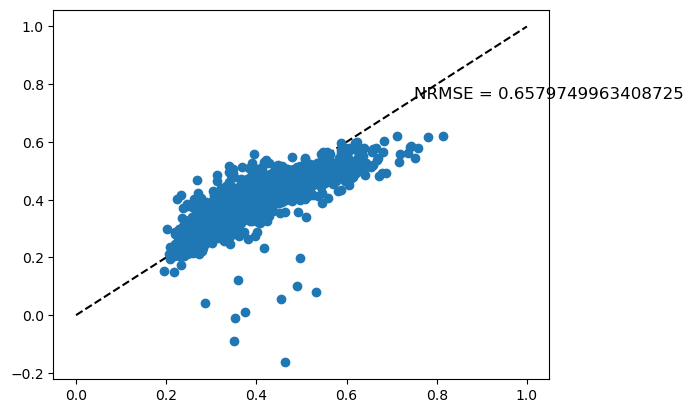

seed warmup: 1234
length warmup: 10
seed NARMA: 1234
Nwarmup: 10
Samples for training:  2000
Samples for test:  1000
Nin = 1 , Nout =  2000 , Nvirt =  40
Deterministic mask will be used
1234
current phase: warmup
p1 in warmup & fast: 0.4999998889492148
current phase: train
p1 in train & fast: [0.49675845]
noise-free training output
restarted
Training data size:  80000
Training data shape:  (2000, 40)
Seed Training: 1234
current phase: test
p1 in test & fast: 0.4999998889492148
noise-free testing output
restarted
Spacer NRMSE:0
0.005299375337904578 0.6565786385875524


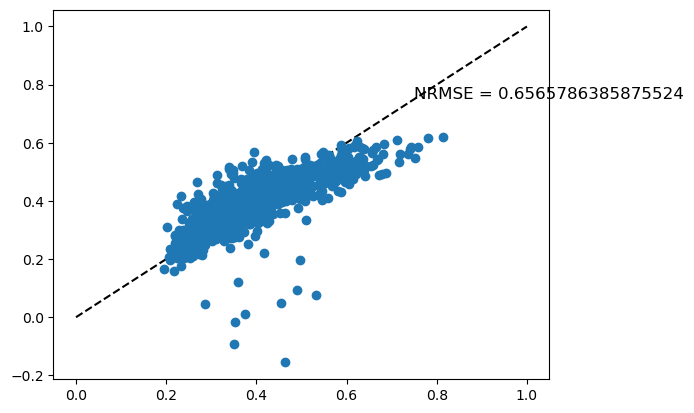

In [4]:
# NARMA10 parameters
Ntrain = 2000
Ntest = 1000
Nwarmup = 10

# Net parameters
Nvirt = 40
m0 = 1e-2
bias = True

# Reservoir parameters
h = 0.4
theta_H = 90
k_s_0 = 0
phi = 45
beta_prime = 10

# Params
params = {
    'theta':1/3, 
    'gamma':.25, 
    'delay_feedback':0, 
    'Nvirt':Nvirt,
    'noise_enable': 'None',
    'noise_seed': 1234,
    'noise_mean':0.0001,
    'noise_std':0.00013,
    'seed_warmup': 1234,
    'length_warmup': Nwarmup,
    'train_sample': Ntrain*Nvirt,
    'test_sample': Ntest*Nvirt,
    'warmup_sample': Nwarmup*Nvirt,
}

spn = spnc_anisotropy(h, theta_H, k_s_0, phi, beta_prime,restart = True,Primep1= None)
transforms = spn.gen_signal_slow_delayed_feedback   
transformf = spn.gen_signal_fast_delayed_feedback

# run
(nrmses,y_test,y_s,y_train,s_s) = ml.spnc_narma10_warmup(Ntrain,Ntest,Nvirt,m0,bias,transforms,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=10)
(nrmsef,y_test,y_f,y_train,s_f) = ml.spnc_narma10_warmup(Ntrain,Ntest,Nvirt,m0,bias,transformf,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=10)

seed warmup: 1234
length warmup: 0
seed NARMA: 1234
Nwarmup: 0
Samples for training:  2000
Samples for test:  1000
Nin = 1 , Nout =  2000 , Nvirt =  40
Deterministic mask will be used
1234
current phase: warmup
p1 in warmup & slow: 0.4999998889492148
current phase: train
p1 in train & slow: 0.4999998889492148
noise_seed: 1234
noise_mean_train: 0.0001
noise-free training output
restarted
Training data size:  80000
Training data shape:  (2000, 40)
Seed Training: 1234
External net will not be used
current phase: test
p1 in test & slow: 0.4999998889492148
noise_seed: 1234
noise_mean_test: 0.0001
noise-free testing output
restarted
Spacer NRMSE:0
0.005249858147796289 0.654718691125495


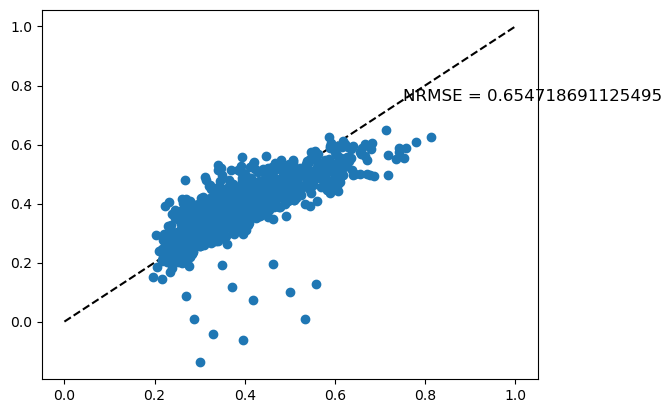

seed warmup: 1234
length warmup: 0
seed NARMA: 1234
Nwarmup: 0
Samples for training:  2000
Samples for test:  1000
Nin = 1 , Nout =  2000 , Nvirt =  40
Deterministic mask will be used
1234
current phase: warmup
p1 in warmup & fast: 0.4999998889492148
current phase: train
p1 in train & fast: 0.4999998889492148
noise-free training output
restarted
Training data size:  80000
Training data shape:  (2000, 40)
Seed Training: 1234
External net will not be used
current phase: test
p1 in test & fast: 0.4999998889492148
noise-free testing output
restarted
Spacer NRMSE:0
0.004155719694704212 0.5825109294768851


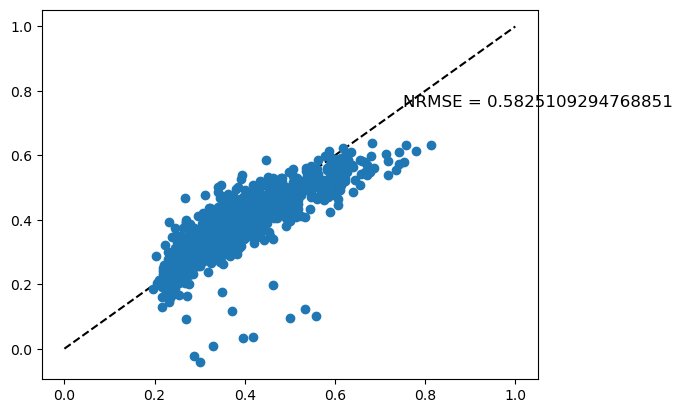

In [7]:
# NARMA10 parameters
Ntrain = 2000
Ntest = 1000
Nwarmup = 0

# Net parameters
Nvirt = 40
m0 = 1e-2
bias = True

# Reservoir parameters
h = 0.4
theta_H = 90
k_s_0 = 0
phi = 45
beta_prime = 10

# Params
params = {
    'theta':1/3, 
    'gamma':.25, 
    'delay_feedback':0, 
    'Nvirt':Nvirt,
    'noise_enable': 'None',
    'noise_seed': 1234,
    'noise_mean':0.0001,
    'noise_std':0.00013,
    'seed_warmup': 1234,
    'length_warmup': Nwarmup,
    'train_sample': Ntrain*Nvirt,
    'test_sample': Ntest*Nvirt,
    'warmup_sample': Nwarmup*Nvirt,
}

spn = spnc_anisotropy(h, theta_H, k_s_0, phi, beta_prime,restart = True,Primep1= None)
transforms = spn.gen_signal_slow_delayed_feedback   
transformf = spn.gen_signal_fast_delayed_feedback

# run
(nrmses,y_test,y_s,y_train,s_s,net_s) = ml.spnc_narma10_weight(Ntrain,Ntest,Nvirt,m0,bias,transforms,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0)
(nrmsef,y_test,y_f,y_train,s_f,net_f) = ml.spnc_narma10_weight(Ntrain,Ntest,Nvirt,m0,bias,transformf,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0)

seed warmup: 1234
length warmup: 0
seed NARMA: 1234
Nwarmup: 0
Samples for training:  2000
Samples for test:  1000
Nin = 1 , Nout =  2000 , Nvirt =  40
Deterministic mask will be used
1234
current phase: warmup
p1 in warmup & slow: 0.4999998889492148
current phase: train
p1 in train & slow: 0.4999998889492148
noise_seed: 1234
noise_mean_train: 0.0001
noise-free training output
restarted
Training data size:  80000
Training data shape:  (2000, 40)
Seed Training: 1234
External net will be used
current phase: test
p1 in test & slow: 0.4999998889492148
noise_seed: 1234
noise_mean_test: 0.0001
noise-free testing output
restarted
Spacer NRMSE:0
92.17521079912 86.75370369788904


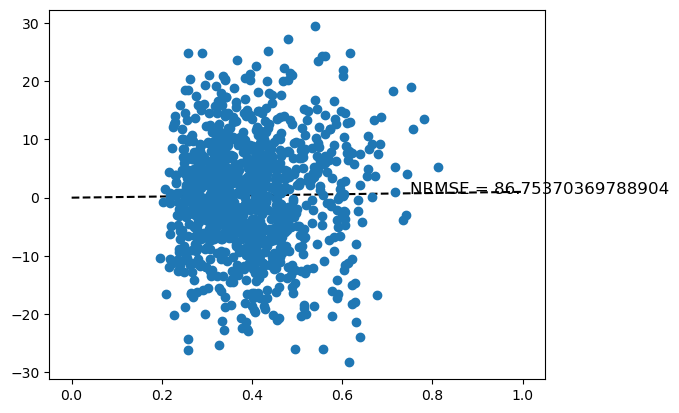

seed warmup: 1234
length warmup: 0
seed NARMA: 1234
Nwarmup: 0
Samples for training:  2000
Samples for test:  1000
Nin = 1 , Nout =  2000 , Nvirt =  40
Deterministic mask will be used
1234
current phase: warmup
p1 in warmup & fast: 0.4999998889492148
current phase: train
p1 in train & fast: 0.4999998889492148
noise-free training output
restarted
Training data size:  80000
Training data shape:  (2000, 40)
Seed Training: 1234
External net will be used
current phase: test
p1 in test & fast: 0.4999998889492148
noise-free testing output
restarted
Spacer NRMSE:0
0.005104126276897997 0.6455675026681559


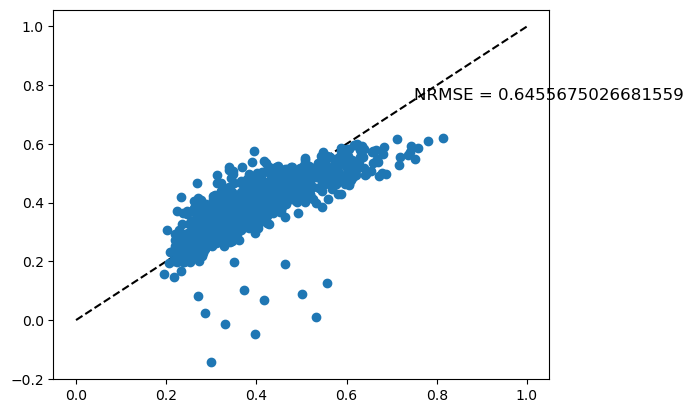

In [8]:
# NARMA10 parameters
Ntrain = 2000
Ntest = 1000
Nwarmup = 0

# Net parameters
Nvirt = 40
m0 = 1e-2
bias = True

# Reservoir parameters
h = 0.4
theta_H = 90
k_s_0 = 0
phi = 45
beta_prime = 10

# Params
params = {
    'theta':1/3, 
    'gamma':.25, 
    'delay_feedback':0, 
    'Nvirt':Nvirt,
    'noise_enable': 'None',
    'noise_seed': 1234,
    'noise_mean':0.0001,
    'noise_std':0.00013,
    'seed_warmup': 1234,
    'length_warmup': Nwarmup,
    'train_sample': Ntrain*Nvirt,
    'test_sample': Ntest*Nvirt,
    'warmup_sample': Nwarmup*Nvirt,
}

spn = spnc_anisotropy(h, theta_H, k_s_0, phi, beta_prime,restart = True,Primep1= None)
transforms = spn.gen_signal_slow_delayed_feedback   
transformf = spn.gen_signal_fast_delayed_feedback

# run
(nrmsesf,y_test,y_sf,y_train,s_sf,net_sf) = ml.spnc_narma10_weight(Ntrain,Ntest,Nvirt,m0,bias,transforms,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0,external_net=net_f)
(nrmsefs,y_test,y_fs,y_train,s_fs,net_fs) = ml.spnc_narma10_weight(Ntrain,Ntest,Nvirt,m0,bias,transformf,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0,external_net=net_s)

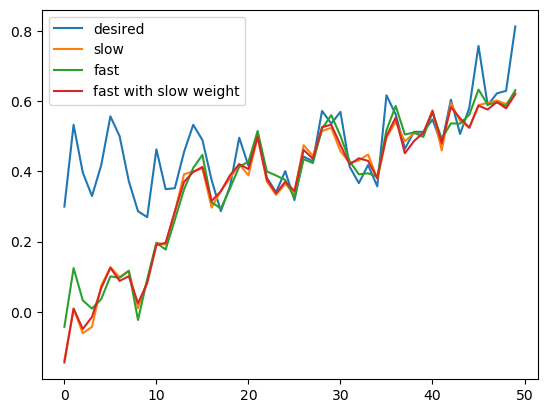

In [18]:
plt.figure()
plt.plot(y_test[:50],label='desired')
plt.plot(y_s[:50],label='slow')
plt.plot(y_f[:50],label='fast')
# plt.plot(y_sf[:50],label='slow with fast weight')
plt.plot(y_fs[:50],label='fast with slow weight')
plt.legend()
plt.show()


In [16]:
print(type(net_s))

<class 'linear_layer.linear'>


In [20]:
print(type(net_s.W))
print(np.shape(net_s.W))

<class 'numpy.ndarray'>
(41, 1)


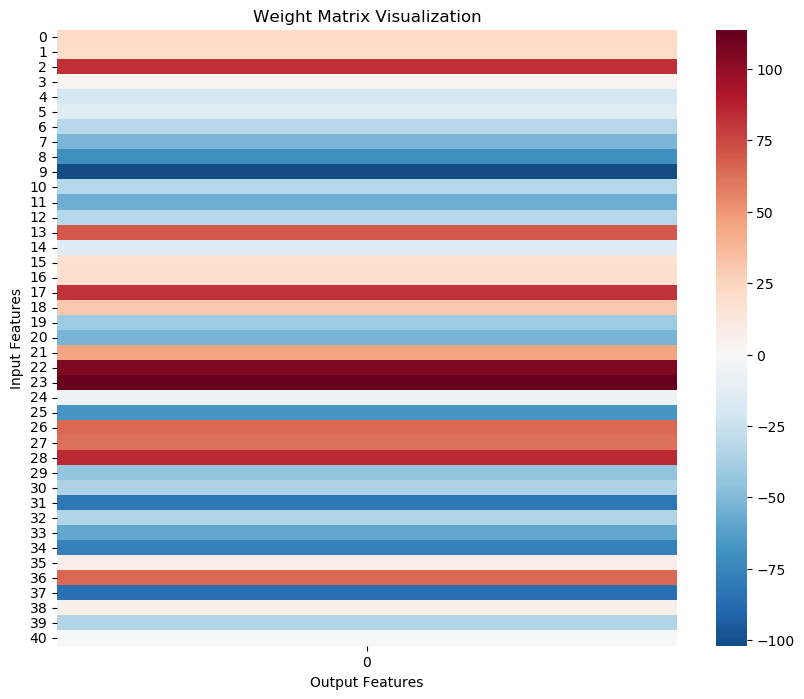

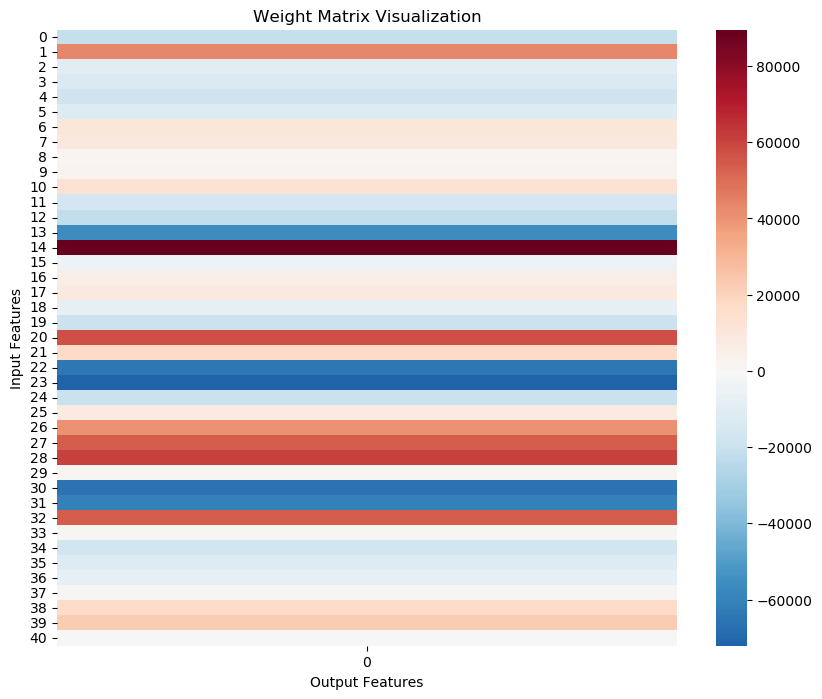

[[  22.60918771]
 [  21.6818327 ]
 [  83.22830114]
 [   3.12883924]
 [ -19.76486099]
 [ -13.41710799]
 [ -31.21792405]
 [ -51.94683349]
 [ -69.80436953]
 [-101.91833662]
 [ -32.48514941]
 [ -54.80783731]
 [ -32.27244511]
 [  70.37156522]
 [ -14.14310904]
 [  17.85718372]
 [  19.09003515]
 [  82.17325157]
 [  30.36867364]
 [ -40.67682539]
 [ -52.89903374]
 [  44.8956369 ]
 [ 105.42986269]
 [ 113.663528  ]
 [  -5.72293251]
 [ -66.61050664]
 [  65.46400803]
 [  62.90929744]
 [  85.52825006]
 [ -44.54645387]
 [ -34.99219867]
 [ -82.39203256]
 [ -33.75694414]
 [ -58.90435647]
 [ -76.14657624]
 [   7.01257396]
 [  64.98381557]
 [ -85.81139407]
 [   5.98551187]
 [ -33.70921125]
 [  -0.14677725]]


In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# 创建热力图
plt.figure(figsize=(10, 8))  # 设置图形大小
sns.heatmap(net_s.W, 
            cmap='RdBu_r',  # 红蓝色配色方案
            center=0,       # 将颜色中心点设为0
            annot=False,    # 是否显示具体数值
            cbar=True)      # 显示颜色条

plt.title('Weight Matrix Visualization')
plt.xlabel('Output Features')
plt.ylabel('Input Features')
plt.show()

# 创建热力图
plt.figure(figsize=(10, 8))  # 设置图形大小
sns.heatmap(net_f.W, 
            cmap='RdBu_r',  # 红蓝色配色方案
            center=0,       # 将颜色中心点设为0
            annot=False,    # 是否显示具体数值
            cbar=True)      # 显示颜色条

plt.title('Weight Matrix Visualization')
plt.xlabel('Output Features')
plt.ylabel('Input Features')
plt.show()

print(net_s.W)

结论：fast得出的权重非常大，说明fast可能存在过拟合的情况。这就是为了slow with fast weight的结果非常差。而slow的权重要小很多，所以fast with slow weight仍然不错的原因。

现在强行将fast使用正则化项，然后查看下交换情况

seed warmup: 1234
length warmup: 0
seed NARMA: 1234
Nwarmup: 0
Samples for training:  2000
Samples for test:  1000
Nin = 1 , Nout =  2000 , Nvirt =  40
Deterministic mask will be used
1234
current phase: warmup
p1 in warmup & slow: 0.4999998889492148
current phase: train
p1 in train & slow: 0.4999998889492148
noise_seed: 1234
noise_mean_train: 0.0001
noise-free training output
restarted
Training data size:  80000
Training data shape:  (2000, 40)
Seed Training: 1234
error with zero =  0.004380562850294669
l= 4.5399929762484854e-05 0.004456481437081064
lambda=4.5399929762484854e-05: MSE=0.004456481437081064
Current weights: [[  7.60437401]
 [  5.8876537 ]
 [ -1.04108387]
 [-16.90186923]
 [-21.76650928]
 [-21.06486875]
 [-25.81491046]
 [-37.35104418]
 [-20.96158947]
 [-16.27331111]
 [ -6.75195342]
 [ -3.57510736]
 [-18.38793318]
 [-12.24282477]
 [-18.36978005]
 [  3.57521584]
 [  3.67813362]
 [  9.84360425]
 [  3.66461435]
 [  8.00757195]
 [ -3.94882413]
 [ 15.23125359]
 [ 27.0735769 ]
 [

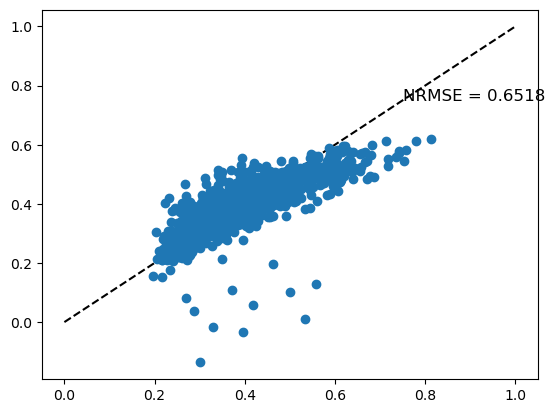

seed warmup: 1234
length warmup: 0
seed NARMA: 1234
Nwarmup: 0
Samples for training:  2000
Samples for test:  1000
Nin = 1 , Nout =  2000 , Nvirt =  40
Deterministic mask will be used
1234
current phase: warmup
p1 in warmup & fast: 0.4999998889492148
current phase: train
p1 in train & fast: 0.4999998889492148
noise-free training output
restarted
Training data size:  80000
Training data shape:  (2000, 40)
Seed Training: 1234
error with zero =  0.0033847981091504574
l= 4.5399929762484854e-05 0.004384336979609115
lambda=4.5399929762484854e-05: MSE=0.004384336979609115
Current weights: [[ 7.47991004e+00]
 [ 8.27565224e+00]
 [-3.06756574e-01]
 [-1.21994233e+01]
 [-2.13063731e+01]
 [-2.56746877e+01]
 [-2.55483963e+01]
 [-3.79817057e+01]
 [-2.32792837e+01]
 [-1.36198407e+01]
 [-8.84363084e+00]
 [-5.26589997e+00]
 [-1.71737374e+01]
 [-1.90104753e+01]
 [-1.68070746e+01]
 [-8.61817048e-03]
 [ 5.22930017e+00]
 [ 5.47756773e+00]
 [ 6.79356102e+00]
 [ 1.08497464e+01]
 [ 1.29891020e+00]
 [ 1.7819400

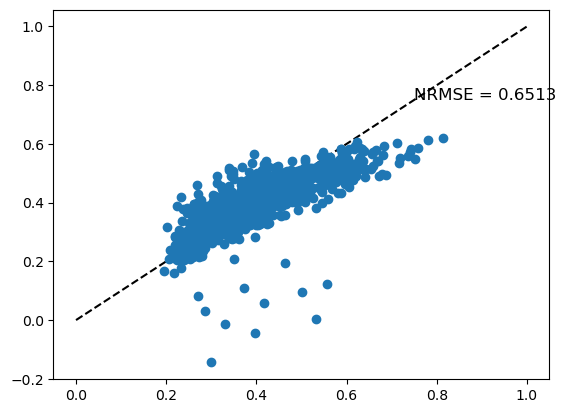

In [4]:
# NARMA10 parameters
Ntrain = 2000
Ntest = 1000
Nwarmup = 0

# Net parameters
Nvirt = 40
m0 = 1e-2
bias = True

# Reservoir parameters
h = 0.4
theta_H = 90
k_s_0 = 0
phi = 45
beta_prime = 10

# Params
params = {
    'theta':1/3, 
    'gamma':.25, 
    'delay_feedback':0, 
    'Nvirt':Nvirt,
    'noise_enable': 'None',
    'noise_seed': 1234,
    'noise_mean':0.0001,
    'noise_std':0.00013,
    'seed_warmup': 1234,
    'length_warmup': Nwarmup,
    'train_sample': Ntrain*Nvirt,
    'test_sample': Ntest*Nvirt,
    'warmup_sample': Nwarmup*Nvirt,
}

spn = spnc_anisotropy(h, theta_H, k_s_0, phi, beta_prime,restart = True,Primep1= None)
transforms = spn.gen_signal_slow_delayed_feedback   
transformf = spn.gen_signal_fast_delayed_feedback

# run
(nrmses,y_tests,y_s,y_trains,s_s,net_s,x_trains,s_trains,x_tests,s_tests) = ml.spnc_narma10_weight(Ntrain,Ntest,Nvirt,m0,bias,transforms,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0)
(nrmsef,y_testf,y_f,y_trainf,s_f,net_f,x_trainf,s_trainf,x_testf,s_testf) = ml.spnc_narma10_weight(Ntrain,Ntest,Nvirt,m0,bias,transformf,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0)

seed warmup: 1234
length warmup: 0
seed NARMA: 1234
Nwarmup: 0
Samples for training:  2000
Samples for test:  1000
Nin = 1 , Nout =  2000 , Nvirt =  40
Deterministic mask will be used
1234
current phase: warmup
p1 in warmup & slow: 0.4999998889492148
current phase: train
p1 in train & slow: 0.4999998889492148
noise_seed: 1234
noise_mean_train: 0.0001
noise-free training output
restarted
Training data size:  80000
Training data shape:  (2000, 40)
Seed Training: 1234
error with zero =  0.004380562850294669
l= 4.5399929762484854e-05 0.004456481437081064
lambda=4.5399929762484854e-05: MSE=0.004456481437081064
Current weights: [[  7.60437401]
 [  5.8876537 ]
 [ -1.04108387]
 [-16.90186923]
 [-21.76650928]
 [-21.06486875]
 [-25.81491046]
 [-37.35104418]
 [-20.96158947]
 [-16.27331111]
 [ -6.75195342]
 [ -3.57510736]
 [-18.38793318]
 [-12.24282477]
 [-18.36978005]
 [  3.57521584]
 [  3.67813362]
 [  9.84360425]
 [  3.66461435]
 [  8.00757195]
 [ -3.94882413]
 [ 15.23125359]
 [ 27.0735769 ]
 [

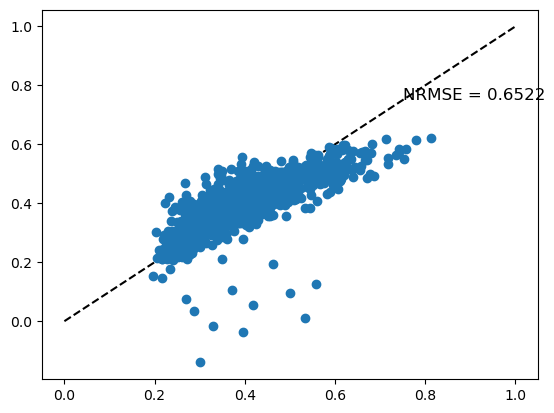

seed warmup: 1234
length warmup: 0
seed NARMA: 1234
Nwarmup: 0
Samples for training:  2000
Samples for test:  1000
Nin = 1 , Nout =  2000 , Nvirt =  40
Deterministic mask will be used
1234
current phase: warmup
p1 in warmup & fast: 0.4999998889492148
current phase: train
p1 in train & fast: 0.4999998889492148
noise-free training output
restarted
Training data size:  80000
Training data shape:  (2000, 40)
Seed Training: 1234
error with zero =  0.0033847981091504574
l= 4.5399929762484854e-05 0.004384336979609115
lambda=4.5399929762484854e-05: MSE=0.004384336979609115
Current weights: [[ 7.47991004e+00]
 [ 8.27565224e+00]
 [-3.06756574e-01]
 [-1.21994233e+01]
 [-2.13063731e+01]
 [-2.56746877e+01]
 [-2.55483963e+01]
 [-3.79817057e+01]
 [-2.32792837e+01]
 [-1.36198407e+01]
 [-8.84363084e+00]
 [-5.26589997e+00]
 [-1.71737374e+01]
 [-1.90104753e+01]
 [-1.68070746e+01]
 [-8.61817048e-03]
 [ 5.22930017e+00]
 [ 5.47756773e+00]
 [ 6.79356102e+00]
 [ 1.08497464e+01]
 [ 1.29891020e+00]
 [ 1.7819400

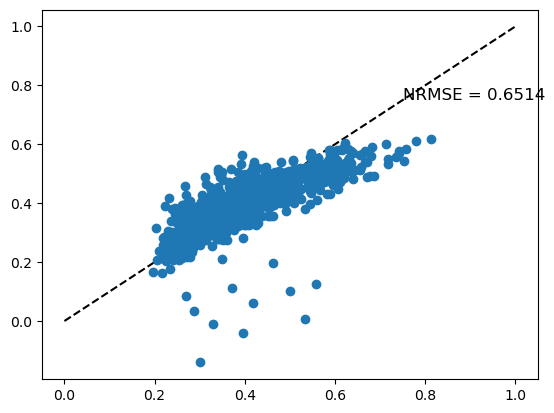

In [6]:
# NARMA10 parameters
Ntrain = 2000
Ntest = 1000
Nwarmup = 0

# Net parameters
Nvirt = 40
m0 = 1e-2
bias = True

# Reservoir parameters
h = 0.4
theta_H = 90
k_s_0 = 0
phi = 45
beta_prime = 10

# Params
params = {
    'theta':1/3, 
    'gamma':.25, 
    'delay_feedback':0, 
    'Nvirt':Nvirt,
    'noise_enable': 'None',
    'noise_seed': 1234,
    'noise_mean':0.0001,
    'noise_std':0.00013,
    'seed_warmup': 1234,
    'length_warmup': Nwarmup,
    'train_sample': Ntrain*Nvirt,
    'test_sample': Ntest*Nvirt,
    'warmup_sample': Nwarmup*Nvirt,
}

spn = spnc_anisotropy(h, theta_H, k_s_0, phi, beta_prime,restart = True,Primep1= None)
transforms = spn.gen_signal_slow_delayed_feedback   
transformf = spn.gen_signal_fast_delayed_feedback

# run
(nrmsesf,y_testsf,y_sf,y_trainsf,s_sf,net_sf,x_trainsf,s_trainsf,x_testsf,s_testsf) = ml.spnc_narma10_weight(Ntrain,Ntest,Nvirt,m0,bias,transforms,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0,external_net=net_f)
(nrmsefs,y_testfs,y_fs,y_trainfs,s_fs,net_fs,x_trainfs,s_trainfs,x_testfs,s_testfs) = ml.spnc_narma10_weight(Ntrain,Ntest,Nvirt,m0,bias,transformf,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0,external_net=net_s)

# See the weight of best optuna hyperparameter tuning 

seed warmup: 1234
length warmup: 0
seed NARMA: 1234
Nwarmup: 0
Samples for training:  2000
Samples for test:  1000
Nin = 1 , Nout =  2000 , Nvirt =  478
Deterministic mask will be used
1234
----------------------
current phase: warmup period
----------------------
Initial p1 in warmup period: 0.4999997880821966
noise-free raw output
----------------------
current phase: train period
----------------------
Initial p1 in train period: 0.4999997880821966
noise-free raw output
reservoir restarted
Training data size:  956000
Training data shape:  (2000, 478)
Seed Training: 1234
error with zero =  0.0036750900301038684
l= 4.5399929762484854e-05 0.0030002082988401504
lambda=4.5399929762484854e-05: MSE=0.0030002082988401504
Current weights: [[ 9.04636855e+00]
 [ 3.27103357e+00]
 [ 1.09464417e-01]
 [ 4.92289352e+00]
 [ 9.56213415e+00]
 [ 1.82293036e+00]
 [-6.88757908e+00]
 [-5.59782210e+00]
 [ 4.46381712e+00]
 [-1.04010120e+00]
 [ 4.81135440e+00]
 [ 6.93292297e+00]
 [ 5.57043496e+00]
 [ 3.84315

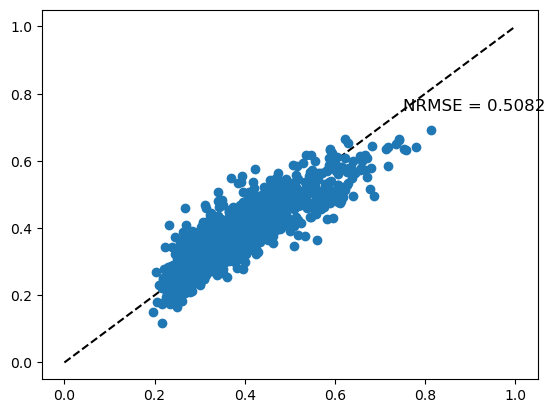

seed warmup: 1234
length warmup: 0
seed NARMA: 1234
Nwarmup: 0
Samples for training:  2000
Samples for test:  1000
Nin = 1 , Nout =  2000 , Nvirt =  478
Deterministic mask will be used
1234
current phase: warmup
p1 in warmup & fast: 0.4999997880821966
current phase: train
p1 in train & fast: 0.4999997880821966
noise-free training output
restarted
Training data size:  956000
Training data shape:  (2000, 478)
Seed Training: 1234
error with zero =  0.0032539812636243268
l= 4.5399929762484854e-05 0.002945554538826368
lambda=4.5399929762484854e-05: MSE=0.002945554538826368
Current weights: [[ 1.24898797e+01]
 [-3.16490565e+00]
 [-4.19043586e+00]
 [ 2.54266575e+00]
 [ 4.32315098e+00]
 [ 9.46630702e-01]
 [-2.57046331e+00]
 [-2.91450347e+00]
 [ 1.72965176e+00]
 [-5.80478221e-01]
 [ 2.84464789e+00]
 [ 5.49254031e+00]
 [ 1.21805887e+00]
 [-2.69168965e+00]
 [-9.07692843e+00]
 [-1.01542374e+01]
 [-9.78356838e+00]
 [-4.96282831e+00]
 [-3.21456843e+00]
 [-2.26750777e+00]
 [-7.06006439e+00]
 [-3.6473

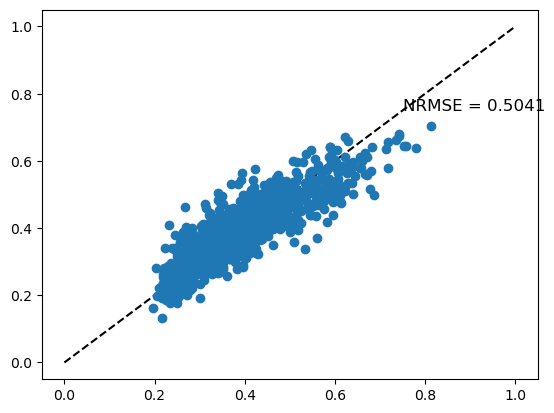

In [5]:
# NARMA10 parameters
Ntrain = 2000
Ntest = 1000
Nwarmup = 0

# Net parameters
Nvirt = 478
m0 = 0.008
bias = True

# Reservoir parameters
h = 0.3049393446125983
theta_H = 90
k_s_0 = 0
phi = 45
beta_prime = 20

# Params
params = {
    'theta':0.7, 
    'gamma':0.17928295809793499, 
    'delay_feedback':0, 
    'Nvirt':Nvirt,
    'noise_enable': 'None',
    'noise_seed': 1234,
    'noise_mean':0.0001,
    'noise_std':0.00013,
    'seed_warmup': 1234,
    'length_warmup': Nwarmup,
    'train_sample': Ntrain*Nvirt,
    'test_sample': Ntest*Nvirt,
    'warmup_sample': Nwarmup*Nvirt,
}

spn = spnc_anisotropy(h, theta_H, k_s_0, phi, beta_prime,restart = True,Primep1= None)
transforms = spn.gen_signal_slow_delayed_feedback   
transformf = spn.gen_signal_fast_delayed_feedback

# run
(nrmsesf,y_testsf,y_sf,y_trainsf,s_sf,net_sf,x_trainsf,s_trainsf,x_testsf,s_testsf) = ml.spnc_narma10_weight(Ntrain,Ntest,Nvirt,m0,bias,transforms,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0)
(nrmsefs,y_testfs,y_fs,y_trainfs,s_fs,net_fs,x_trainfs,s_trainfs,x_testfs,s_testfs) = ml.spnc_narma10_weight(Ntrain,Ntest,Nvirt,m0,bias,transformf,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0)

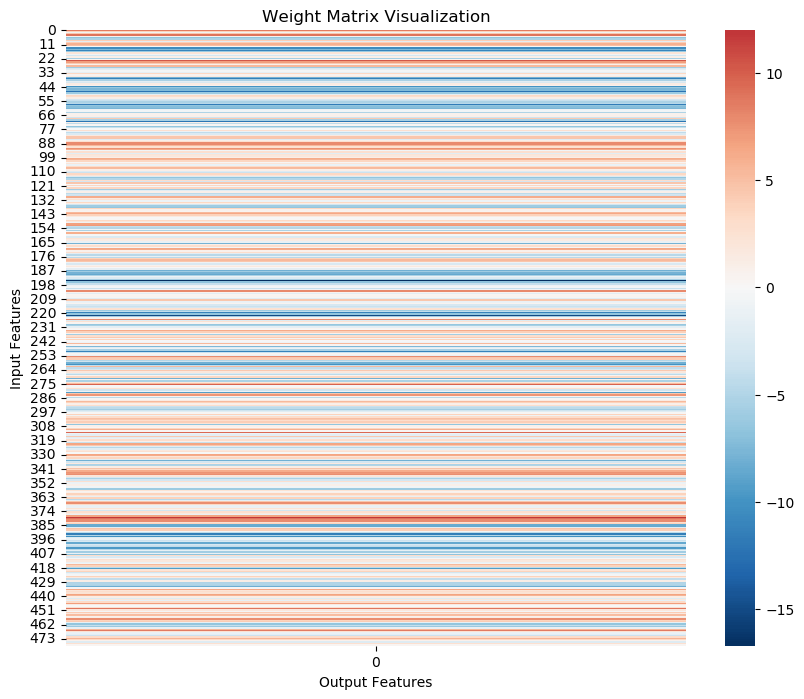

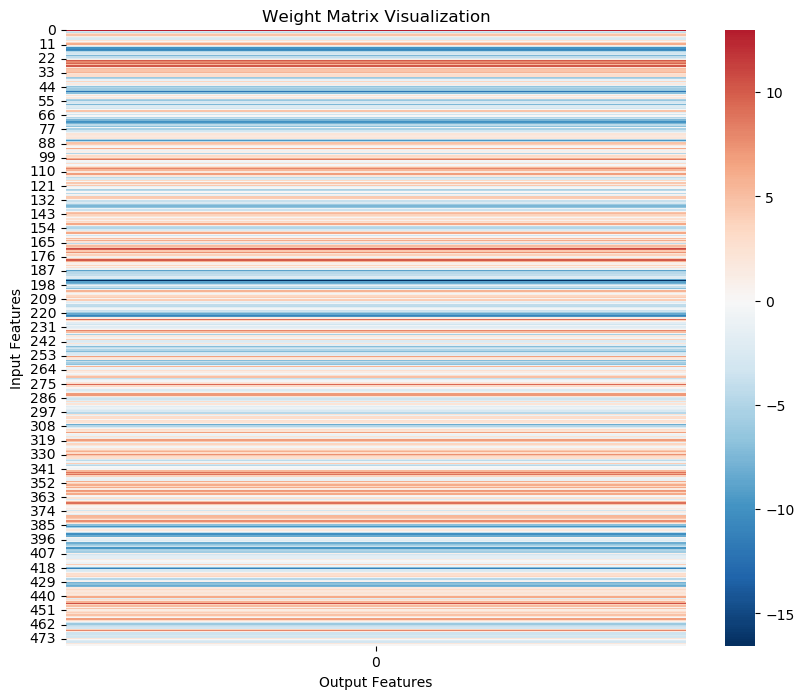

NameError: name 'net_s' is not defined

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# 创建热力图
plt.figure(figsize=(10, 8))  # 设置图形大小
sns.heatmap(net_sf.W, 
            cmap='RdBu_r',  # 红蓝色配色方案
            center=0,       # 将颜色中心点设为0
            annot=False,    # 是否显示具体数值
            cbar=True)      # 显示颜色条

plt.title('Weight Matrix Visualization')
plt.xlabel('Output Features')
plt.ylabel('Input Features')
plt.show()

# 创建热力图
plt.figure(figsize=(10, 8))  # 设置图形大小
sns.heatmap(net_fs.W, 
            cmap='RdBu_r',  # 红蓝色配色方案
            center=0,       # 将颜色中心点设为0
            annot=False,    # 是否显示具体数值
            cbar=True)      # 显示颜色条

plt.title('Weight Matrix Visualization')
plt.xlabel('Output Features')
plt.ylabel('Input Features')
plt.show()

print(net_s.W)